# Function 1 — Week 8: Hurdle Model with Weighted UCB, Local Penalization & Interior Penalty

**Iteration**: Week 8 (18 observations: 10 initial + 8 weekly submissions)  
**Strategy**: Same as Week 7 — two-stage hurdle model surrogate with weighted UCB acquisition, local penalization, and interior penalty.  
**Goal**: Propose next sample point for Function 1 (2D radiation source detection).

### Strategy Summary

F1 has returned **zero improvement** across multiple consecutive submissions. The landscape is dominated by zero/negative outputs, meaning the radiation source has not yet been located. The strategy remains **exploration-focused** (κ = 3.0) with three key components:

1. **Hurdle Model (Surrogate)**: Two-stage approach handling zero-inflated outputs:
   - *Stage 1 — Classifier*: `CalibratedClassifierCV(LogisticRegression)` estimates P(y > 0)
   - *Stage 2 — Regressor*: `RandomForestRegressor` on log1p(y) for positive outputs (or fallback to pure exploration if < 3 positive samples)

2. **Weighted UCB Acquisition**: $a(x) = p(x) \cdot \mu(x) + \kappa \cdot p(x) \cdot \sigma_{\text{RF}}(x)$

3. **Penalties**: Local penalization (Gaussian mask over all evaluated points) + Interior penalty (sinusoidal boundary suppression)

This notebook is **self-contained** per constitution principle III.

In [1]:
# --- Imports ---
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestRegressor

## Hyperparameters

All tunable parameters for the Week 8 hurdle model, acquisition function, local penalization, and interior penalty. These are **identical to Week 7** — no changes justified given the continued lack of improvement.

| Parameter | Value | Rationale |
|-----------|-------|----------|
| **C_STAGE1** | 1.0 | Default L2 regularisation for LogisticRegression; balanced for 18-sample dataset. |
| **N_ESTIMATORS** | 100 | Standard RF ensemble size; provides stable uncertainty from per-tree prediction std. |
| **MAX_DEPTH** | 3 | Constrains tree depth to prevent overfitting with few positive-output samples. |
| **KAPPA** | 3.0 | Exploration-focused UCB weight. F1 has shown no improvement — exploitation is deprioritised. |
| **PENALTY_RADIUS** | 0.15 | ~10.6% of input-space diagonal. Prevents re-sampling near evaluated points. |
| **N_CANDIDATES** | 20000 | Dense uniform coverage of 2D space for acquisition maximisation. |
| **GRID_RES** | 50 | 50×50 = 2500 grid points for visualisation. |
| **MIN_POSITIVE** | 3 | Minimum positive samples for Stage 2 RF training; below this triggers fallback. |
| **STEEPNESS** | 0.1 | Interior penalty exponent — reduced from spec-014 default of 2.0 in Week 7 for gentler boundary suppression, allowing candidates closer to edges. |
| **FLOOR** | 0.01 | Interior penalty minimum at boundary — prevents exact zeros in acquisition. |

In [2]:
# --- Hyperparameter Constants ---
# All tunable values defined here for auditability and easy adjustment.
C_STAGE1       = 1.0      # Logistic Regression regularisation strength
N_ESTIMATORS   = 100      # Number of Random Forest trees in Stage 2
MAX_DEPTH      = 3        # Maximum tree depth — constrains overfitting
KAPPA          = 3.0      # UCB exploration parameter (exploration-focused)
PENALTY_RADIUS = 0.15     # Gaussian penalization radius
N_CANDIDATES   = 20_000   # Number of random UCB candidates
GRID_RES       = 50       # Visualization grid resolution (50x50)
MIN_POSITIVE   = 3        # Minimum positive-output samples for Stage 2
STEEPNESS      = 0.1      # Interior penalty boundary suppression exponent
FLOOR          = 0.01     # Interior penalty minimum weight at boundary

print("Week 8 Hyperparameters:")
print(f"  C_STAGE1:       {C_STAGE1}")
print(f"  N_ESTIMATORS:   {N_ESTIMATORS}")
print(f"  MAX_DEPTH:      {MAX_DEPTH}")
print(f"  KAPPA:          {KAPPA}")
print(f"  PENALTY_RADIUS: {PENALTY_RADIUS}")
print(f"  N_CANDIDATES:   {N_CANDIDATES}")
print(f"  GRID_RES:       {GRID_RES}")
print(f"  MIN_POSITIVE:   {MIN_POSITIVE}")
print(f"  STEEPNESS:      {STEEPNESS}")
print(f"  FLOOR:          {FLOOR}")

Week 8 Hyperparameters:
  C_STAGE1:       1.0
  N_ESTIMATORS:   100
  MAX_DEPTH:      3
  KAPPA:          3.0
  PENALTY_RADIUS: 0.15
  N_CANDIDATES:   20000
  GRID_RES:       50
  MIN_POSITIVE:   3
  STEEPNESS:      0.1
  FLOOR:          0.01


## Step 1: Load and Validate Week 8 Data

Load the updated Week 8 data containing all 18 observations (10 initial + 8 weekly submissions). Validate shapes, ranges, and derive the binary labels needed for the hurdle model.

In [3]:
# --- Load and Validate Week 8 Data ---
X = np.load('../../data/f1/updated_inputs - Week 8.npy')
y = np.load('../../data/f1/updated_outputs - Week 8.npy')

# Shape validation
assert X.shape == (18, 2), f"Unexpected input shape: {X.shape} (expected (18, 2))"
assert y.shape == (18,),   f"Unexpected output shape: {y.shape} (expected (18,))"

# Range validation
assert X.min() >= 0.0 and X.max() <= 1.0, \
    f"Inputs out of valid range: [{X.min():.6f}, {X.max():.6f}]"
assert not np.any(np.isnan(y)), "NaN values found in outputs!"
assert not np.any(np.isinf(y)), "Inf values found in outputs!"

print(f"Week 8 Data — {X.shape[0]} samples, {X.shape[1]} inputs each")
print(f"Input range: [{X.min():.6f}, {X.max():.6f}] ✓ within [0.0, 1.0]")
print(f"Outputs — min: {y.min():.6e}  max: {y.max():.6e}  mean: {y.mean():.6e}")

Week 8 Data — 18 samples, 2 inputs each
Input range: [0.000330, 0.999460] ✓ within [0.0, 1.0]
Outputs — min: -3.606063e-03  max: 7.710875e-16  mean: -2.609608e-04


In [4]:
# --- Derived Binary Labels for Hurdle Model ---
y_binary  = y > 0                  # (18,) bool — binary label for Stage 1
n_positive = int(y_binary.sum())
X_pos      = X[y_binary]           # (n_positive, 2) — positive subset for Stage 2
y_pos      = y[y_binary]           # (n_positive,)
y_pos_log  = np.log1p(y_pos)       # log1p-transformed targets for Stage 2

FALLBACK_MODE = n_positive < MIN_POSITIVE

print(f"Positive outputs (y > 0): {n_positive}/{len(y)}")
print(f"FALLBACK_MODE: {FALLBACK_MODE}")

if FALLBACK_MODE:
    print(f"\n⚠ WARNING: Only {n_positive} positive sample(s) detected. "
          f"Stage 2 requires ≥ {MIN_POSITIVE}. "
          f"FALLBACK_MODE = True — Stage 2 will be skipped; "
          f"acquisition falls back to pure exploration.")
else:
    print(f"\n✓ Sufficient positive samples for Stage 2 training.")

Positive outputs (y > 0): 12/18
FALLBACK_MODE: False

✓ Sufficient positive samples for Stage 2 training.


### Data Summary

Display all 18 input/output data points in tabular format, highlighting the current best observation.

In [5]:
# --- Tabular Data Display ---
best_idx = np.argmax(y)
best_val = y[best_idx]

print(f"{'Obs':>4}  {'x1':>10}  {'x2':>10}  {'y':>12}  {'Label':>6}")
print("-" * 52)
for i in range(len(y)):
    label = "POS" if y_binary[i] else "NEG/0"
    marker = " ★ BEST" if i == best_idx else ""
    print(f"{i+1:>4}  {X[i,0]:>10.6f}  {X[i,1]:>10.6f}  {y[i]:>12.6e}  {label:>6}{marker}")

print(f"\nBest observed value: {best_val:.6e} at observation {best_idx + 1}")
print(f"Best location: ({X[best_idx, 0]:.6f}, {X[best_idx, 1]:.6f})")

 Obs          x1          x2             y   Label
----------------------------------------------------
   1    0.319404    0.762959  1.322677e-79     POS
   2    0.574329    0.879898  1.033078e-46     POS
   3    0.731024    0.733000  7.710875e-16     POS ★ BEST
   4    0.840353    0.264732  3.341771e-124     POS
   5    0.650114    0.681526  -3.606063e-03   NEG/0
   6    0.410437    0.147554  -2.159249e-54   NEG/0
   7    0.312691    0.078723  -2.089093e-91   NEG/0
   8    0.683418    0.861057  2.535001e-40     POS
   9    0.082507    0.403488  3.606771e-81     POS
  10    0.883890    0.582254  6.229856e-48     POS
  11    0.448979    0.142857  2.314081e-56     POS
  12    0.708964    0.494269  -1.159884e-17   NEG/0
  13    0.986481    0.986619  4.977703e-180     POS
  14    0.060194    0.333985  2.842720e-97     POS
  15    0.740501    0.838613  1.018730e-40     POS
  16    0.003918    0.999460  0.000000e+00   NEG/0
  17    0.004402    0.000330  1.874280e-245     POS
  18    0.43276

## Step 2: Fit Hurdle Model Surrogate

### Stage 1 — Calibrated Logistic Classifier for P(y > 0)

The classifier estimates the probability that a candidate location yields a **positive** output. `CalibratedClassifierCV` with `method='sigmoid'` (Platt scaling) ensures well-calibrated probabilities. `class_weight='balanced'` handles the class imbalance (few or no positive samples).

In [6]:
# --- Stage 1: Logistic Regression Classifier for P(y > 0) ---
stage1_base = LogisticRegression(C=C_STAGE1, max_iter=1000, class_weight='balanced')
stage1_clf  = CalibratedClassifierCV(stage1_base, cv=3, method='sigmoid')
stage1_clf.fit(X, y_binary)

# Training probability estimates
p_train    = stage1_clf.predict_proba(X)[:, 1]
y_pred_bin = stage1_clf.predict(X)
acc_stage1 = (y_pred_bin == y_binary).mean()

print("Stage 1 — Logistic Regression (CalibratedClassifierCV)")
print(f"  Training accuracy: {acc_stage1:.4f}")
print(f"  Positive-class training probabilities:")
print(f"    min: {p_train.min():.4f}  max: {p_train.max():.4f}  mean: {p_train.mean():.4f}")

Stage 1 — Logistic Regression (CalibratedClassifierCV)
  Training accuracy: 0.6667
  Positive-class training probabilities:
    min: 0.5505  max: 0.6826  mean: 0.6302


### Stage 2 — Random Forest Regressor on log1p(y) for Positive Outputs

If at least `MIN_POSITIVE` (3) positive samples exist, Stage 2 fits a `RandomForestRegressor` on the log1p-transformed positive outputs to estimate magnitude and uncertainty. If fewer positive samples exist (**FALLBACK_MODE**), Stage 2 is skipped and the acquisition function degrades to pure exploration (μ=0, σ=1).

In [7]:
# --- Stage 2: Random Forest Regressor on log1p(y) for y > 0 ---
if not FALLBACK_MODE:
    stage2_rf = RandomForestRegressor(
        n_estimators=N_ESTIMATORS,
        max_depth=MAX_DEPTH,
        random_state=42,
    )
    stage2_rf.fit(X_pos, y_pos_log)

    r2_stage2 = stage2_rf.score(X_pos, y_pos_log)
    print("Stage 2 — Random Forest Regressor on log1p(y) for y > 0")
    print(f"  Training R²:  {r2_stage2:.4f}  (on log scale)")
    print(f"  Number of trees: {N_ESTIMATORS}")
    print(f"  Max depth:       {MAX_DEPTH}")
    print(f"  Samples used:    {len(X_pos)} (all y > 0)")
else:
    stage2_rf = None
    print("⚠ Stage 2 SKIPPED — FALLBACK_MODE active")
    print(f"  Only {n_positive} positive sample(s) detected (need ≥ {MIN_POSITIVE}).")
    print(f"  Acquisition will use μ=0, σ=1 (pure exploration).")

Stage 2 — Random Forest Regressor on log1p(y) for y > 0
  Training R²:  -0.0009  (on log scale)
  Number of trees: 100
  Max depth:       3
  Samples used:    12 (all y > 0)


## Step 3: Acquisition Function — Weighted UCB with Local Penalization & Interior Penalty

The acquisition function combines three components:

1. **Weighted UCB**: $a(x) = p(x) \cdot \mu(x) + \kappa \cdot p(x) \cdot \sigma_{\text{RF}}(x)$  
   The classifier probability $p(x)$ weights both exploitation and exploration terms, suppressing acquisition in regions unlikely to yield positive outputs.

2. **Local Penalization**: $\text{penalty}(x) = \prod_{i=1}^{18}\left(1 - e^{-\|x - x_i\|^2 / (2r^2)}\right)$  
   Gaussian mask over all 18 evaluated points, discouraging re-sampling near previously sampled locations.

3. **Interior Penalty**: $w(x) = \text{FLOOR} + (1 - \text{FLOOR}) \cdot \prod_{i=1}^{d} \sin(\pi x_i)^{2 \cdot \text{STEEPNESS}}$  
   Smooth boundary suppression preventing edge clustering. Equals FLOOR at any edge and 1.0 at the centre.

**Final acquisition**: $a_{\text{final}}(x) = a(x) \cdot \text{penalty}(x) \cdot w(x)$

In [8]:
# --- Weighted UCB with Local Penalization & Interior Penalty ---
np.random.seed(42)
X_cand = np.random.uniform(0.0, 0.999999, size=(N_CANDIDATES, 2))

# Stage 1: P(y > 0) for every candidate
p_cand = stage1_clf.predict_proba(X_cand)[:, 1]

if not FALLBACK_MODE:
    # Stage 2: per-tree predictions for uncertainty estimation
    tree_preds_cand = np.array([tree.predict(X_cand) for tree in stage2_rf.estimators_])
    mu_log_cand     = tree_preds_cand.mean(axis=0)   # mean on log scale
    sigma_rf_cand   = tree_preds_cand.std(axis=0)    # std across trees (log scale)
    mu_cand         = np.expm1(mu_log_cand)           # back-transform: expm1 inverts log1p
else:
    # Fallback: no Stage 2 — use pure exploration (μ=0, σ=1)
    mu_cand       = np.zeros(N_CANDIDATES)
    sigma_rf_cand = np.ones(N_CANDIDATES)

# Weighted UCB: a(x) = p(x)·μ(x) + κ·p(x)·σ_RF(x)
acq_raw = p_cand * mu_cand + KAPPA * p_cand * sigma_rf_cand

# Local penalization: multiplicative Gaussian mask over all 18 existing data points
# penalty(x) = ∏_i [1 - exp(-‖x - xᵢ‖² / (2r²))]
penalty = np.ones(N_CANDIDATES)
for xi in X:
    dist_sq = np.sum((X_cand - xi) ** 2, axis=1)
    penalty *= (1.0 - np.exp(-dist_sq / (2 * PENALTY_RADIUS ** 2)))

# Interior penalty: w(x) = FLOOR + (1 - FLOOR) * prod_i sin(π·xᵢ)^(2·STEEPNESS)
interior_weight = FLOOR + (1.0 - FLOOR) * np.prod(
    np.sin(np.pi * X_cand) ** (2 * STEEPNESS), axis=1
)

# Combined acquisition: UCB × local penalty × interior penalty
acq_final = acq_raw * penalty * interior_weight

# Select the candidate with the highest final acquisition value
best_idx_acq = np.argmax(acq_final)
next_x = np.clip(X_cand[best_idx_acq], 0.0, 0.999999)

# Safety check: minimum distance to any existing data point
min_dist = float(np.min(np.sqrt(np.sum((X - next_x) ** 2, axis=1))))

print("Weighted UCB with Local Penalization & Interior Penalty")
print(f"  κ = {KAPPA} (exploration-focused)")
print(f"  Penalization radius r = {PENALTY_RADIUS} (all {len(X)} evaluated points)")
print(f"  Interior penalty: STEEPNESS={STEEPNESS}, FLOOR={FLOOR}")
print(f"  Interior weight range: [{interior_weight.min():.6f}, {interior_weight.max():.6f}]")
print(f"  Best final acquisition score: {acq_final[best_idx_acq]:.6f}")
print(f"  Next candidate: [{next_x[0]:.6f}, {next_x[1]:.6f}]")
print(f"  Min distance to existing data: {min_dist:.4f}  (must be ≥ 0.05)")
if min_dist < 0.05:
    print("  ⚠ WARNING: selected point is closer than 0.05 to an existing sample!")
else:
    print("  ✓ Distance check passed")

Weighted UCB with Local Penalization & Interior Penalty
  κ = 3.0 (exploration-focused)
  Penalization radius r = 0.15 (all 18 evaluated points)
  Interior penalty: STEEPNESS=0.1, FLOOR=0.01
  Interior weight range: [0.100514, 0.999991]
  Best final acquisition score: 0.000000
  Next candidate: [0.797902, 0.037269]
  Min distance to existing data: 0.2314  (must be ≥ 0.05)
  ✓ Distance check passed


In [9]:
# --- Validation and Submission Formatting ---
next_x_clipped = np.clip(next_x, 0.0, 0.999999)

# Validation
assert next_x_clipped.shape == (2,), f"Expected 2D point, got shape {next_x_clipped.shape}"
assert np.all(next_x_clipped >= 0.0) and np.all(next_x_clipped <= 0.999999), \
    f"Point out of [0, 0.999999] range: {next_x_clipped}"

# Minimum distance check
min_dist_check = float(np.min(np.sqrt(np.sum((X - next_x_clipped) ** 2, axis=1))))
if min_dist_check < 0.05:
    print(f"⚠ WARNING: Min distance {min_dist_check:.4f} < 0.05. "
          f"Consider increasing N_CANDIDATES or relaxing constraint.")

x1_str = f"{next_x_clipped[0]:.6f}"
x2_str = f"{next_x_clipped[1]:.6f}"
formatted_query = f"{x1_str}-{x2_str}"

print("=" * 60)
print("WEEK 8 SUBMISSION QUERY FOR FUNCTION 1")
print("=" * 60)
print(f"  Surrogate:         Hurdle Model (LR Classifier + RF Regressor)")
print(f"  Acquisition:       Weighted UCB (κ={KAPPA}) + Local Penalty (r={PENALTY_RADIUS})")
print(f"  Interior Penalty:  sin²-product (STEEPNESS={STEEPNESS}, FLOOR={FLOOR})")
print(f"  Strategy:          EXPLORATION — no improvement over previous submissions")
print(f"  FALLBACK_MODE:     {FALLBACK_MODE}")
print(f"  x1 = {x1_str}  x2 = {x2_str}")
print(f"  Formatted: {formatted_query}")
print("=" * 60)
print(f"\nWeek 8 Submission Query: {formatted_query}")

WEEK 8 SUBMISSION QUERY FOR FUNCTION 1
  Surrogate:         Hurdle Model (LR Classifier + RF Regressor)
  Acquisition:       Weighted UCB (κ=3.0) + Local Penalty (r=0.15)
  Interior Penalty:  sin²-product (STEEPNESS=0.1, FLOOR=0.01)
  Strategy:          EXPLORATION — no improvement over previous submissions
  FALLBACK_MODE:     False
  x1 = 0.797902  x2 = 0.037269
  Formatted: 0.797902-0.037269

Week 8 Submission Query: 0.797902-0.037269


## Step 4: Visualisation

### 3-Panel Contour Plot

1. **Hurdle Mean Prediction**: $\hat{y} = p(x) \cdot \text{expm1}(\mu(x))$ — predicted output magnitude
2. **Hurdle Uncertainty**: $p(x) \cdot \sigma_{\text{RF}}(x)$ — weighted uncertainty estimate
3. **Penalised Acquisition Surface**: Final acquisition after UCB × local penalty × interior penalty

Training points are colour-coded: **red** = positive outputs (y > 0), **blue** = non-positive. The proposed next point is marked with a **yellow star**.

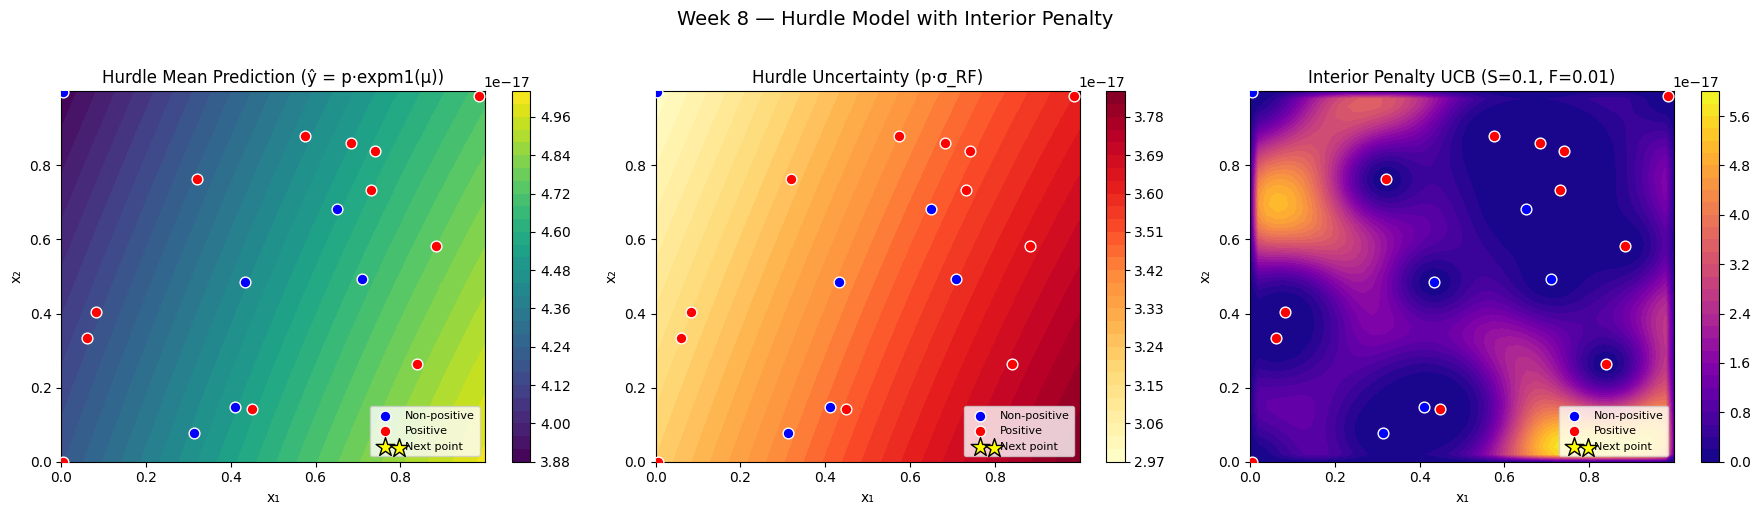

In [10]:
# --- 3-Panel Contour Plot ---
# Build a uniform visualization grid
x1_vis = np.linspace(0.0, 0.999999, GRID_RES)
x2_vis = np.linspace(0.0, 0.999999, GRID_RES)
X1_vis, X2_vis = np.meshgrid(x1_vis, x2_vis)
X_grid = np.column_stack([X1_vis.ravel(), X2_vis.ravel()])

# Stage 1 probabilities on the grid
p_grid = stage1_clf.predict_proba(X_grid)[:, 1]

if not FALLBACK_MODE:
    # Stage 2: per-tree predictions on the grid
    tree_preds_grid = np.array([tree.predict(X_grid) for tree in stage2_rf.estimators_])
    mu_log_grid     = tree_preds_grid.mean(axis=0)
    sigma_rf_grid   = tree_preds_grid.std(axis=0)
    mu_grid         = np.expm1(mu_log_grid)
    acq_raw_grid    = p_grid * mu_grid + KAPPA * p_grid * sigma_rf_grid
    grid_hurdle      = (p_grid * mu_grid).reshape(GRID_RES, GRID_RES)
    grid_uncertainty = (p_grid * sigma_rf_grid).reshape(GRID_RES, GRID_RES)
else:
    acq_raw_grid     = p_grid.copy()
    grid_hurdle      = p_grid.reshape(GRID_RES, GRID_RES)
    grid_uncertainty = p_grid.reshape(GRID_RES, GRID_RES)

# Local penalization on the grid
penalty_grid = np.ones(len(X_grid))
for xi in X:
    dist_sq_grid = np.sum((X_grid - xi) ** 2, axis=1)
    penalty_grid *= (1.0 - np.exp(-dist_sq_grid / (2 * PENALTY_RADIUS ** 2)))

# Interior penalty on the grid
interior_weight_grid = FLOOR + (1.0 - FLOOR) * np.prod(
    np.sin(np.pi * X_grid) ** (2 * STEEPNESS), axis=1
)

# Combined acquisition: UCB × local penalty × interior penalty
grid_ucb = (acq_raw_grid * penalty_grid * interior_weight_grid).reshape(GRID_RES, GRID_RES)

# Colour split: red = positive-output training points, blue = non-positive
pos_mask = y > 0

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Hurdle Mean Prediction
ax1 = axes[0]
c1 = ax1.contourf(X1_vis, X2_vis, grid_hurdle, levels=30, cmap='viridis')
ax1.scatter(X[~pos_mask, 0], X[~pos_mask, 1], c='blue', edgecolors='white', s=60, zorder=5, label='Non-positive')
ax1.scatter(X[pos_mask, 0], X[pos_mask, 1], c='red', edgecolors='white', s=60, zorder=5, label='Positive')
ax1.scatter(next_x[0], next_x[1], c='yellow', marker='*', s=200, edgecolors='black', zorder=6, label='Next point')
ax1.set_xlabel('x₁'); ax1.set_ylabel('x₂')
ax1.set_title('Hurdle Mean Prediction (ŷ = p·expm1(μ))')
ax1.legend(loc='lower right', fontsize=8)
plt.colorbar(c1, ax=ax1)

# Panel 2: Hurdle Uncertainty (p·σ_RF)
ax2 = axes[1]
c2 = ax2.contourf(X1_vis, X2_vis, grid_uncertainty, levels=30, cmap='YlOrRd')
ax2.scatter(X[~pos_mask, 0], X[~pos_mask, 1], c='blue', edgecolors='white', s=60, zorder=5, label='Non-positive')
ax2.scatter(X[pos_mask, 0], X[pos_mask, 1], c='red', edgecolors='white', s=60, zorder=5, label='Positive')
ax2.scatter(next_x[0], next_x[1], c='yellow', marker='*', s=200, edgecolors='black', zorder=6, label='Next point')
ax2.set_xlabel('x₁'); ax2.set_ylabel('x₂')
ax2.set_title('Hurdle Uncertainty (p·σ_RF)')
ax2.legend(loc='lower right', fontsize=8)
plt.colorbar(c2, ax=ax2)

# Panel 3: Penalized UCB with Interior Penalty
ax3 = axes[2]
c3 = ax3.contourf(X1_vis, X2_vis, grid_ucb, levels=30, cmap='plasma')
ax3.scatter(X[~pos_mask, 0], X[~pos_mask, 1], c='blue', edgecolors='white', s=60, zorder=5, label='Non-positive')
ax3.scatter(X[pos_mask, 0], X[pos_mask, 1], c='red', edgecolors='white', s=60, zorder=5, label='Positive')
ax3.scatter(next_x[0], next_x[1], c='yellow', marker='*', s=200, edgecolors='black', zorder=6, label='Next point')
ax3.set_xlabel('x₁'); ax3.set_ylabel('x₂')
ax3.set_title(f'Interior Penalty UCB (S={STEEPNESS}, F={FLOOR})')
ax3.legend(loc='lower right', fontsize=8)
plt.colorbar(c3, ax=ax3)

plt.suptitle('Week 8 — Hurdle Model with Interior Penalty', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

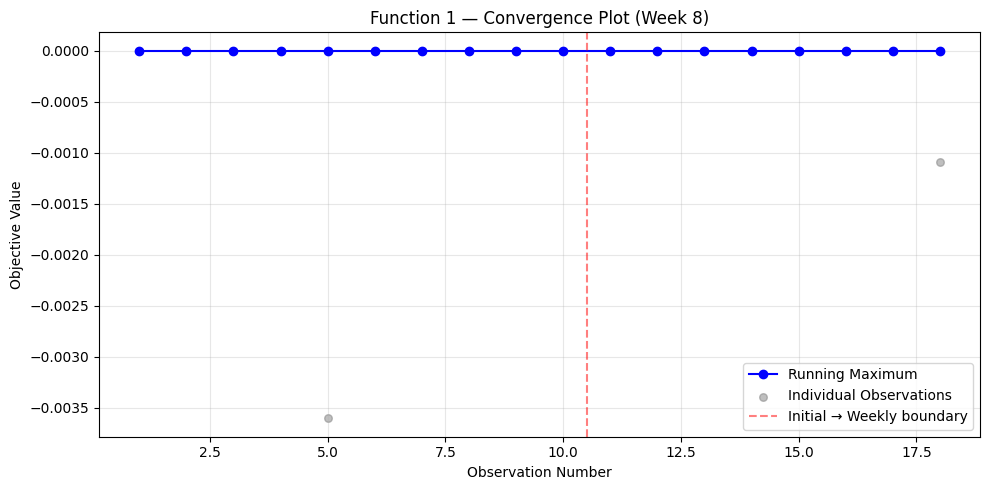

Best observed value: 7.710875e-16  (observation 3)
Best location: (0.731024, 0.733000)


In [11]:
# --- Convergence Plot ---
running_max = np.maximum.accumulate(y)

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(y) + 1), running_max, 'b-o', markersize=6, label='Running Maximum')
plt.scatter(range(1, len(y) + 1), y, c='gray', alpha=0.5, s=30, label='Individual Observations')
plt.axvline(x=10.5, color='red', linestyle='--', alpha=0.5, label='Initial → Weekly boundary')
plt.xlabel('Observation Number')
plt.ylabel('Objective Value')
plt.title('Function 1 — Convergence Plot (Week 8)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Best observed value: {y.max():.6e}  (observation {y.argmax() + 1})")
print(f"Best location: ({X[y.argmax(), 0]:.6f}, {X[y.argmax(), 1]:.6f})")